In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("pca.csv")

In [2]:
cols = ["Precio", "Expensas", "Dormitorios", "Banos", "Ambientes", "Antiguedad", "Sup_Cubierta_m2", "Sup_Total_m2", "Precio_m2", "Proporcion_Cubierta"]

df = df[cols]

df[cols] = StandardScaler().fit_transform(df[cols])

Correlaciones altas en valor absoluto (> 0.60)
Sup_Cubierta_m2  Sup_Total_m2       0.953643
Dormitorios      Ambientes          0.927116
Ambientes        Sup_Cubierta_m2    0.798815
Dormitorios      Sup_Cubierta_m2    0.789362
Ambientes        Sup_Total_m2       0.771414
Dormitorios      Sup_Total_m2       0.760832
Precio           Sup_Cubierta_m2    0.753446
                 Expensas           0.745190
                 Sup_Total_m2       0.744455
Banos            Sup_Cubierta_m2    0.716516
                 Sup_Total_m2       0.700896
Precio           Banos              0.652764
Expensas         Sup_Cubierta_m2    0.638204
                 Sup_Total_m2       0.617793
Dormitorios      Banos              0.602898
dtype: float64


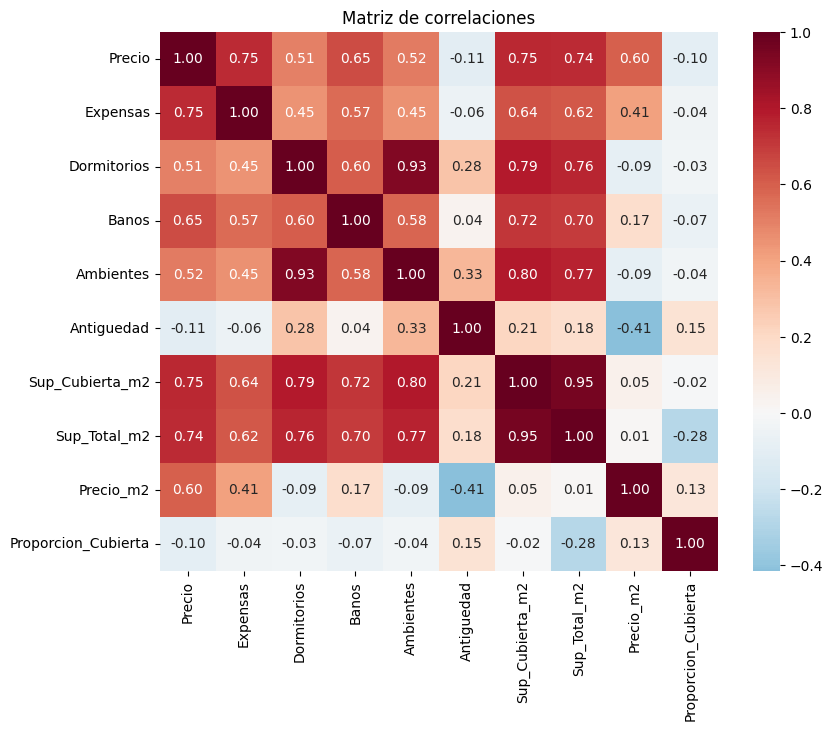

In [3]:
# Correlaciones entre variables

X = df.copy()

corr = X.corr()

print('Correlaciones altas en valor absoluto (> 0.60)')
pares = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(pares[pares > 0.60].sort_values(ascending=False))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matriz de correlaciones')
plt.show()

In [4]:
# ESTANDARIZAR
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# OBJETO PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [5]:
# ME QUEDO CON LOS AUTOVALORES > 1 SEGÚN CRITERIO DE KAISER

autovalores = pca.explained_variance_



# 2. Mostrarlos con un formato claro
for i, val in enumerate(autovalores):
    print(f"Autovalor PC{i+1}: {val:.4f}")

Autovalor PC1: 5.1680
Autovalor PC2: 1.9295
Autovalor PC3: 1.1274
Autovalor PC4: 0.5620
Autovalor PC5: 0.4281
Autovalor PC6: 0.3663
Autovalor PC7: 0.2848
Autovalor PC8: 0.0715
Autovalor PC9: 0.0528
Autovalor PC10: 0.0109


Contribución de variables (valores absolutos):
                          PC1       PC2       PC3
Precio               0.365377  0.335499  0.026394
Expensas             0.325914  0.274935  0.062034
Dormitorios          0.371461  0.241345  0.047500
Banos                0.352919  0.066536  0.006639
Ambientes            0.373513  0.254810  0.052280
Antiguedad           0.072630  0.529586  0.281520
Sup_Cubierta_m2      0.417791  0.076109  0.046570
Sup_Total_m2         0.411954  0.075746  0.194317
Precio_m2            0.080270  0.626261  0.229771
Proporcion_Cubierta  0.047517  0.007368  0.904680


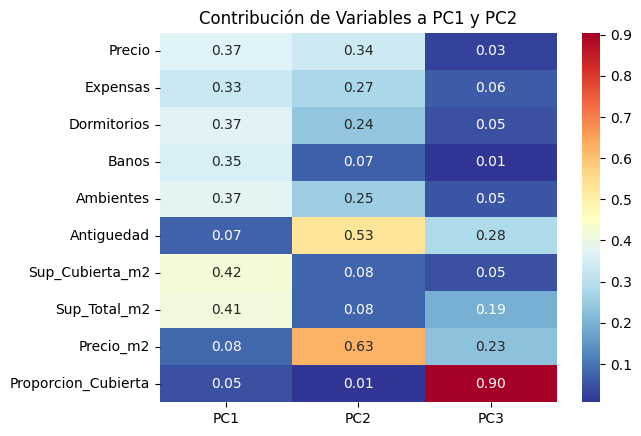

In [6]:
# Contribución de cada variable a cada componente
contributions = pd.DataFrame(
    np.abs(pca.components_).T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=X.columns
)

print("Contribución de variables (valores absolutos):")
print(contributions[['PC1', 'PC2', 'PC3']])  # Ajusta según cuántos PCs quieras

# Visualización
sns.heatmap(contributions[['PC1', 'PC2', 'PC3']], annot=True, fmt='.2f', cmap='RdYlBu_r')
plt.title('Contribución de Variables a PC1 y PC2')
plt.show()

Componente 1: 0.5167 | Acumulada: 0.5167
Componente 2: 0.1929 | Acumulada: 0.7097
Componente 3: 0.1127 | Acumulada: 0.8224
Componente 4: 0.0562 | Acumulada: 0.8786
Componente 5: 0.0428 | Acumulada: 0.9214
Componente 6: 0.0366 | Acumulada: 0.9580
Componente 7: 0.0285 | Acumulada: 0.9865
Componente 8: 0.0072 | Acumulada: 0.9936
Componente 9: 0.0053 | Acumulada: 0.9989
Componente 10: 0.0011 | Acumulada: 1.0000


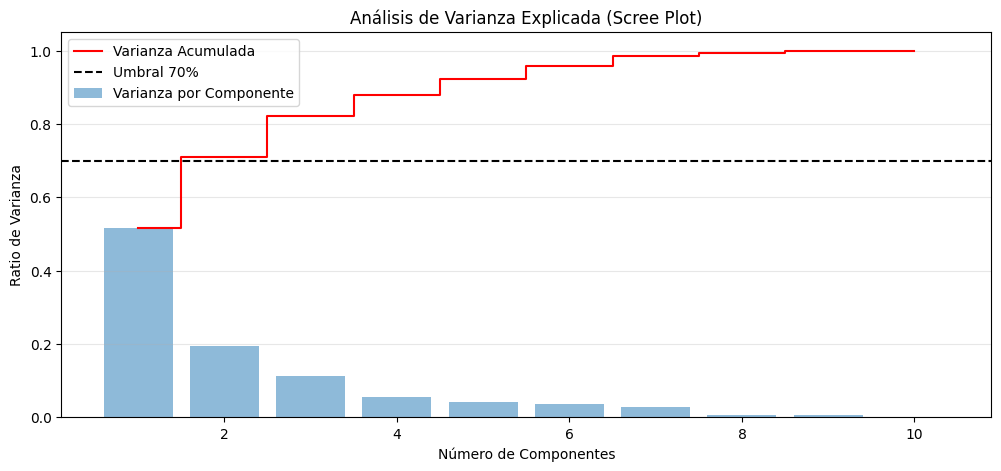

In [7]:
plt.figure(figsize=(12, 5))
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

for i in range(len(exp_var)):
    print(f"Componente {i+1}: {exp_var[i]:.4f} | Acumulada: {cum_var[i]:.4f}")

plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.5, label='Varianza por Componente')
plt.step(range(1, len(cum_var)+1), cum_var, where='mid', label='Varianza Acumulada', color='red')
plt.axhline(y=0.7, color='black', linestyle='--', label='Umbral 70%')
plt.title('Análisis de Varianza Explicada (Scree Plot)')
plt.xlabel('Número de Componentes')
plt.ylabel('Ratio de Varianza')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

De acuerdo al criterio de Kaiser, nos quedamos solamente con 3 componentes principales. COn dichos componentes podriamos estar explicando un 82% de la variabilidad total de nuestras variables numericas.

De todas formas, decidimos no avanzar con las componentes y quedarnos con las variables originales. Las razones son:

1. No son demasiadas variables, por lo que no hace falta reducir la dimensionalidad para reducir el tiempo de entrenamiento de un modelo de manera significativa

2. Nos importa la interpretación de las variables originales. Al quedarnos con los componentes principales, perdemos la interpretación de las variables. En este caso, dado el contexto de negocio, nos interesa la interpretación

3. Era esperable encontrar componentes que puedan explicar en conjunto a columnas como baño, ambientes, dormitorios o sueprficie cubierta, dado que muchas veces algunas dependen de otras (a mas ambientes se espera una mayor superficie), aunque se decidio quedar con las variables originales, dado que nos interesaba su interpretación exacta. 